In [83]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf
import matplotlib.ticker as mtick
import statsmodels.api as sm
from scipy import stats
import pandas_datareader as pdr

### **Setting Parameters** [IMPORTANT] ###

I think for now let's just assume monthly = true

In [84]:
monthly = True # set "monthly = false" if we're using daily returns.
# This will change the ENTIRE output of the program so use carefully.

start_date = ""  #Date format: yyyy-mm-dd
end_date = ""  #leave these blank ("") if no specific start / end date

fund_data_path = "M:/_Intern Folder/Matthew/Parkman Data Analysis Project/PHP_Fund_Returns_Monthly.xlsx" # Must be in .xlsx format
# Must have only 2 columns called Date and Return (in decimals)

### Data Pulling & Cleaning ###

In [85]:
#Get fund returns data (depends on fund)
fund_data_path
fund_data = pd.read_excel(fund_data_path)  
fund_data = fund_data[['Date', 'Return']].dropna() 

# Prepare fund returns
fund_data['Date'] = pd.to_datetime(fund_data['Date'])
fund_data = fund_data.set_index('Date').sort_index()
# Returns must be in decimals (no percentages)

fund_data

,Return
Date,
2019-06-30,0.0085
2019-07-31,-0.0154
2019-08-31,-0.0289
2019-09-30,-0.0367
2019-10-31,0.0280
...,...
2025-09-30,0.0246
2025-10-31,0.0187
2025-11-30,0.0344


In [86]:
import io, zipfile, re, requests

# pandas_datareader's famafrench module uses HTTP which now 404s.
# Download directly via HTTPS instead.
_FF_BASE = "https://mba.tuck.dartmouth.edu/pages/faculty/ken.french/ftp"
_FF_NAME = "F-F_Research_Data_Factors"  # 3-factor model (Mkt-RF, SMB, HML)

resp = requests.get(f"{_FF_BASE}/{_FF_NAME}_CSV.zip")
resp.raise_for_status()

with zipfile.ZipFile(io.BytesIO(resp.content)) as zf:
    csv_name = [n for n in zf.namelist() if n.lower().endswith(".csv")][0]
    raw = zf.read(csv_name).decode("utf-8")

# The CSV has header text, then monthly data, then annual data.
# Parse only the first numeric block (monthly table).
blocks = re.split(r'\n\s*\n', raw.strip())

header_line = None
data_lines = []
for block in blocks:
    lines = block.strip().splitlines()
    for i, line in enumerate(lines):
        first_token = line.strip().split(",")[0].strip()
        if first_token.isdigit() and len(first_token) >= 6:
            if header_line is None:
                header_line = lines[i - 1] if i > 0 else "Date,Mkt-RF,SMB,HML,RF"
            data_lines.append(line)
    if data_lines:
        break

csv_text = header_line.strip() + "\n" + "\n".join(data_lines)
ff3 = pd.read_csv(io.StringIO(csv_text))
ff3.columns = ff3.columns.str.strip()
ff3 = ff3.rename(columns={ff3.columns[0]: "Date"})
ff3["Date"] = pd.to_datetime(ff3["Date"].astype(str), format="%Y%m")
ff3 = ff3.set_index("Date")
ff3.index = ff3.index.to_period("M").to_timestamp("M")  # align to month-end
ff3 = ff3[ff3.index >= "2000-01-01"]

print(f"Loaded {_FF_NAME}: {ff3.shape[0]} rows x {ff3.shape[1]} cols")
ff3 = ff3/100
ff3.head()


Loaded F-F_Research_Data_Factors: 313 rows x 4 cols


,Mkt-RF,SMB,HML,RF
Date,,,,
2000-01-31,-0.0474,0.0516,-0.0112,0.0041
2000-02-29,0.0246,0.2125,-0.0977,0.0043
2000-03-31,0.0521,-0.1741,0.0850,0.0047
2000-04-30,-0.0639,-0.0600,0.0645,0.0046
2000-05-31,-0.0439,-0.0608,0.0459,0.0050


In [87]:
#get fund returns
fund_rets = fund_data['Return']

#SANITY CHECKS


# Align series on common dates
df = pd.concat([fund_rets, ff3], axis=1, join='inner')

# Check if start / end date is specified
if start_date != "" and end_date != "":
    df = df.loc[start_date:end_date]
elif start_date != "" and end_date == "":
    df = df.loc[start_date:]
elif start_date == "" and end_date != "":
    df = df.loc[:end_date]

fund_data_concatenated = df.copy()

df['Return-RF'] = df['Return'] - df['RF']
df

,Return,Mkt-RF,SMB,HML,RF,Return-RF
Date,,,,,,
2019-06-30,0.0085,0.0699,0.0011,-0.0064,0.0018,0.0067
2019-07-31,-0.0154,0.0123,-0.0196,0.0050,0.0019,-0.0173
2019-08-31,-0.0289,-0.0255,-0.0239,-0.0477,0.0016,-0.0305
2019-09-30,-0.0367,0.0141,-0.0097,0.0676,0.0018,-0.0385
2019-10-31,0.0280,0.0207,0.0027,-0.0192,0.0015,0.0265
...,...,...,...,...,...,...
2025-09-30,0.0246,0.0339,-0.0185,-0.0105,0.0033,0.0213
2025-10-31,0.0187,0.0196,-0.0055,-0.0310,0.0037,0.0150
2025-11-30,0.0344,-0.0013,0.0038,0.0376,0.0030,0.0314


In [95]:
#check if any data is lost
fund_data_concatenated = df.copy()

removed = (
    fund_data.reset_index()
    .merge(
        fund_data_concatenated.reset_index(),
        on='Date',
        how='left',
        indicator=True
    )
    .query('_merge == "left_only"')
    .set_index('Date')
)

removed

,Return_x,Return_y,Mkt-RF,SMB,HML,RF,Return-RF,Alpha,Cumulative Alpha,_merge
Date,,,,,,,,,,


### Finding Beta & Alpha + Testing statistical significance of Alpha ###

In [96]:
alpha_color = "#f90e0eff"
beta_color = '#009efb'

y = df['Return-RF']

x = sm.add_constant(df[['Mkt-RF', 'SMB', 'HML']])

results = sm.OLS(y, x).fit()
alpha = results.params['const']
beta = results.params['Mkt-RF']
smb = results.params['SMB']
hml = results.params['HML']
p_value_alpha = results.pvalues['const'] / 2

results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:              Return-RF   R-squared:                       0.184
Model:                            OLS   Adj. R-squared:                  0.152
Method:                 Least Squares   F-statistic:                     5.725
Date:                Tue, 17 Mar 2026   Prob (F-statistic):            0.00138
Time:                        18:26:10   Log-Likelihood:                 199.33
No. Observations:                  80   AIC:                            -390.7
Df Residuals:                      76   BIC:                            -381.1
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0056      0.002      2.360      0.021       0.001       0.010
Mkt-RF         0.1165      0.049      2.354      0.021       0.018       0.215
SMB            0.1943      0.084      2.303      0.024       0.026       0.362
HML            0.0416      0.053      0.782      0.436      -0.064       0.148
==============================================================================
Omnibus:                        1.278   Durbin-Watson:                   1.828
Prob(Omnibus):                  0.528   Jarque-Bera (JB):                0.737
Skew:                           0.190   Prob(JB):                        0.692
Kurtosis:                       3.277   Cond. No.                         37.8
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [99]:
# Build summary table from regression results
factors = ['const', 'Mkt-RF', 'SMB', 'HML']
labels = ['Alpha', 'Beta (Mkt-RF)', 'SMB', 'HML']

rows = []
for factor, label in zip(factors, labels):
    coef = results.params[factor]
    t_stat = results.tvalues[factor]
    p_two = results.pvalues[factor]
    p_one = p_two / 2
    sig = "Yes" if p_one < 0.05 else "No"
    stars = "***" if p_one < 0.01 else "**" if p_one < 0.05 else "*" if p_one < 0.10 else ""
    rows.append([label, f"{coef:.6f}", f"{t_stat:.4f}", f"{p_two:.5f}", f"{p_one:.5f}", sig, stars])

header = f"{'Factor':<18} {'Coefficient':>14} {'t-Statistic':>14} {'P (2-tail)':>14} {'P (1-tail)':>14} {'Sig (5%)':>10} {'':>4}"
print("=" * 95)
print(f"{'Fama-French 3-Factor Regression Results':^95}")
print("=" * 95)
print(header)
print("-" * 95)
for row in rows:
    print(f"{row[0]:<18} {row[1]:>14} {row[2]:>14} {row[3]:>14} {row[4]:>14} {row[5]:>10} {row[6]:>4}")
print("=" * 95)
print("Significance: *** p<0.01  ** p<0.05  * p<0.10  (one-tailed)")
print(f"R-squared: {results.rsquared:.4f}    Adj. R-squared: {results.rsquared_adj:.4f}    Obs: {int(results.nobs)}")
print("=" * 95)


                            Fama-French 3-Factor Regression Results                            
Factor                Coefficient    t-Statistic     P (2-tail)     P (1-tail)   Sig (5%)     
-----------------------------------------------------------------------------------------------
Alpha                    0.005644         2.3601        0.02084        0.01042        Yes   **
Beta (Mkt-RF)            0.116516         2.3539        0.02116        0.01058        Yes   **
SMB                      0.194256         2.3032        0.02400        0.01200        Yes   **
HML                      0.041641         0.7823        0.43646        0.21823         No     
Significance: *** p<0.01  ** p<0.05  * p<0.10  (one-tailed)
R-squared: 0.1843    Adj. R-squared: 0.1521    Obs: 80


### Investigating Alpha Decay using Time-Series analysis: Method #1 -- Exponential Decay ###

Paper: https://ink.library.smu.edu.sg/cgi/viewcontent.cgi?article=5734&context=lkcsb_research

"Have Capital Market Anomalies Attenuated in the Recent Era of High Liquidity and Trading Activity?" -- Section 4.3

Goal: Regress alpha data onto this curve: 

$$Y_t = a \cdot e^{bt + u_t}$$

Taking logs linearizes it: 

$$\ln(Y_t) = \ln(a) + b \cdot t + u $$

where $$Y_t = 1 + alpha_t$$

Null hypothesis: Anomalous profits (alpha) decrease exponentially over time.

Alternative hypothesis: Anomalous profits (alpha) don't decrease exponentially over time.

**Interpretation**: 

- If b < 0 and one-tailed p-value < 0.10, the strategy is experiencing statistically significant exponential decay in alpha.

- If b > 0 and one-tailed p-value < 0.10, the strategy is experiencing statistically significant exponential growth in alpha.

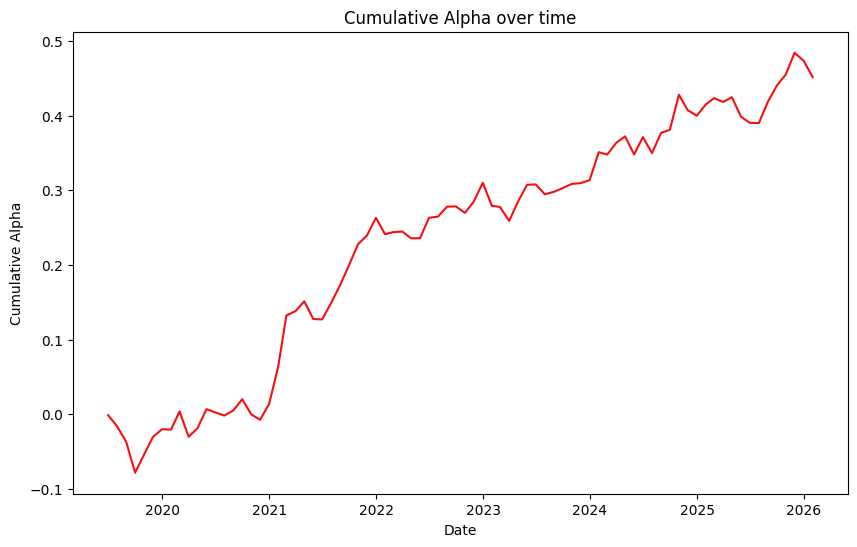

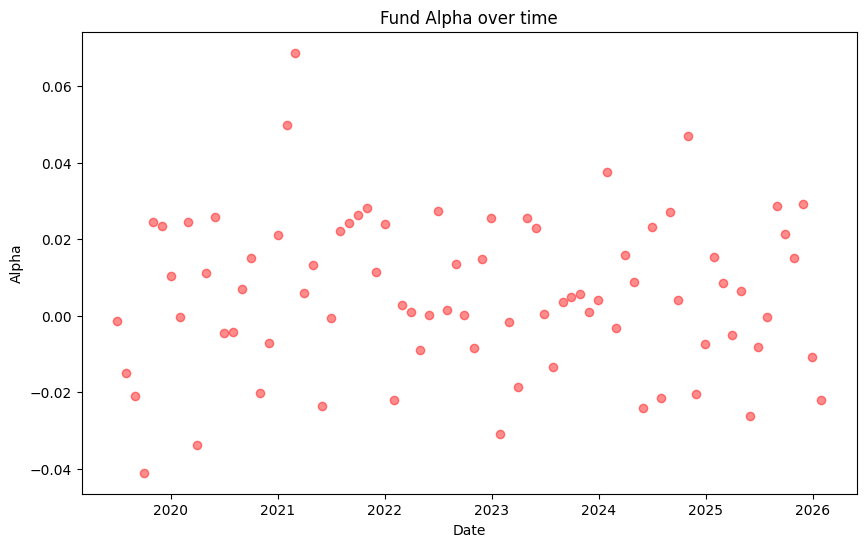

In [91]:
df['Alpha'] = df['Return-RF'] - (df['Mkt-RF'] * beta + df['SMB'] * smb + df['HML'] * hml)
df['Cumulative Alpha'] = df['Alpha'].cumsum()

fig, ax = plt.subplots(figsize=(10,6))
plt.title("Cumulative Alpha over time")
ax.set_xlabel("Date")
ax.set_ylabel("Cumulative Alpha")
ax.plot(df.index, df['Cumulative Alpha'], color="#f90e0eff")

fig, ax = plt.subplots(figsize=(10,6))
plt.title("Fund Alpha over time")
ax.set_xlabel("Date")
ax.set_ylabel("Alpha")
plt.scatter(df.index, df['Alpha'], alpha=0.45, color="#ff0000ff")
df

df.to_csv("alpha_output.csv")

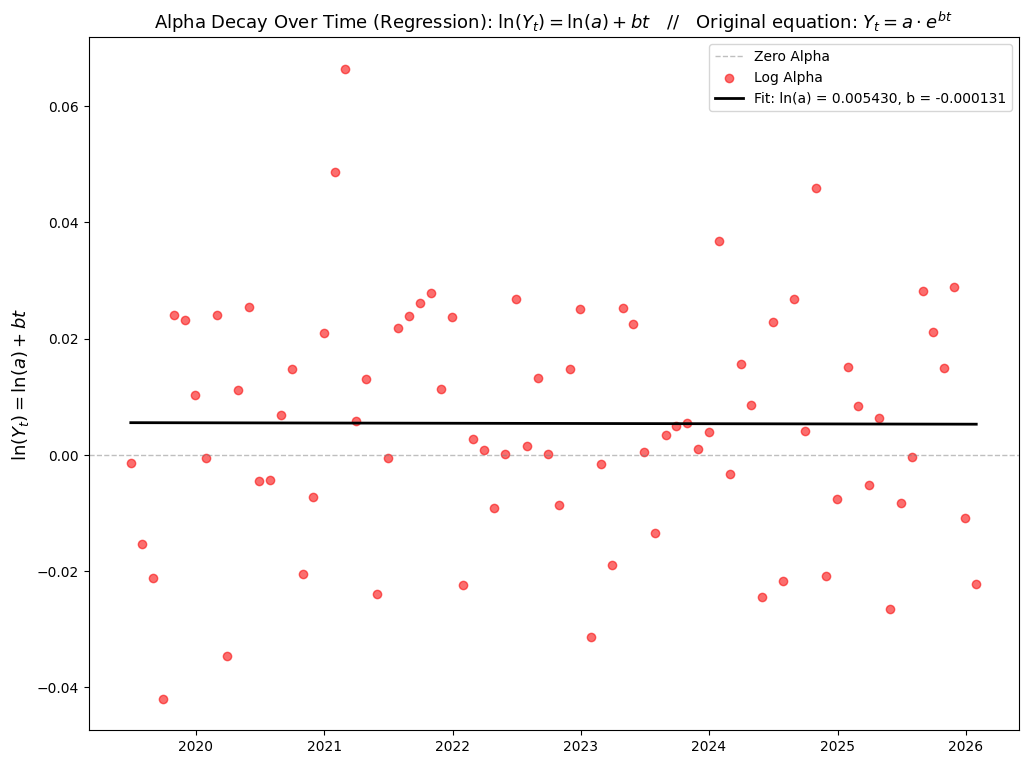

Note: This assumes that there exists a statistically significant alpha. If there is none, this decay result is pointless.
Condition: If p-value (one-tailed) < 0.10 and b < 0 (is negative), alpha decay is present at the 10% SL.
--------------------------------------------------
The p-value of the regression coefficient b (0.48645) is statistically insignificant.
There is insufficient evidence to suggest alpha decay.


In [92]:
df_alpha = df[['Alpha', 'Cumulative Alpha']].copy()
df_alpha['Log Alpha'] = np.log(1 + df_alpha['Alpha'])
df_alpha

array = np.linspace(-1, 1, len(df_alpha))
array = sm.add_constant(array)
model = sm.OLS(df_alpha['Log Alpha'], array)
results = model.fit()
# print(results.summary())

# ln_Yt = results.params['const'] + np.linspace(-1, 1, len(df_alpha)) * results.params['x1']
ln_Yt = results.fittedvalues
Y_t = np.exp(ln_Yt)

ln_a = results.params['const']
a = np.exp(ln_a)
b = results.params['x1']
p_decay_onetailed = results.pvalues['x1'] / 2

fig, ax = plt.subplots(figsize=(12,9))
ax.axhline(y=0, color='gray', linestyle='--', linewidth=1, alpha=0.5, label="Zero Alpha")
plt.scatter(df_alpha.index, df_alpha['Log Alpha'], alpha=0.6, color="#f90e0eff", label="Log Alpha")
plt.title("Alpha Decay Over Time (Regression): $\ln(Y_t) = \ln(a) + bt$   //   Original equation: $Y_t = a \cdot e^{bt}$", fontsize=13)
plt.plot(
    df_alpha.index, 
    ln_Yt,
    color="#000000",
    linewidth=2,
    label=f"Fit: ln(a) = {ln_a:.6f}, b = {b:.6f}"
)
ax.set_ylabel("$\ln(Y_t) = \ln(a) + bt$", fontsize=13)
plt.legend()
plt.show()

print("Note: This assumes that there exists a statistically significant alpha. If there is none, this decay result is pointless.")
print("Condition: If p-value (one-tailed) < 0.10 and b < 0 (is negative), alpha decay is present at the 10% SL.")
print("-" * 50)

if p_decay_onetailed < 0.1 and b < 0: 
    print(f"The p-value of the regression coefficient b ({p_decay_onetailed:.5f}) is statistically significant.")
    print("There is sufficient evidence to suggest alpha decay.")
elif p_decay_onetailed > 0.1 and b < 0: 
    print(f"The p-value of the regression coefficient b ({p_decay_onetailed:.5f}) is statistically insignificant.")
    print("There is insufficient evidence to suggest alpha decay.")
elif b > 0 and p_decay_onetailed < 0.1: 
    print(f"The p-value of the regression coefficient coefficient b ({p_decay_onetailed:.5f}) is statistically significant.")
    print(f"Rare case: The fund's alpha actually increases over time and is significant enough.")
elif b > 0 and p_decay_onetailed > 0.1:
    print(f"b is positive but insignificant (p = {p_decay_onetailed:.5f}).")
    print("There is insufficient evidence of either decay or growth in alpha.")

### Plotting cumulative returns, Sharpe, and rolling market volatility ###

In [93]:
# if monthly == True:
#     #Sharpe and volatility -- monthly
#     fund_excess_vol = df['Fund Excess'].std()
#     fund_excess_vol_annualized = fund_excess_vol * np.sqrt(12)
#     fund_sharpe_annualized = (df['Fund Excess'].mean() / fund_excess_vol) * np.sqrt(12)

#     mkt_excess_vol = df['Market Excess'].std()
#     mkt_excess_vol_annualized = mkt_excess_vol * np.sqrt(12)
#     mkt_sharpe_annualized = (df['Market Excess'].mean() / mkt_excess_vol) * np.sqrt(12)

# else:
#     # Sharpe and volatility -- daily
#     fund_excess_vol = df['Fund Excess'].std()
#     fund_excess_vol_annualized = fund_excess_vol * np.sqrt(252)
#     fund_sharpe_annualized = (df['Fund Excess'].mean() / fund_excess_vol) * np.sqrt(252)

#     mkt_excess_vol = df['Market Excess'].std()
#     mkt_excess_vol_annualized = mkt_excess_vol * np.sqrt(252)
#     mkt_sharpe_annualized = (df['Market Excess'].mean() / mkt_excess_vol) * np.sqrt(252)

# # --- Fund ---
# fund_gross = (1 + fund_data["Return"].astype(float)).cumprod() #gross cumulative

# if monthly == True:
#     mkt_d = market_data["market_rets"].dropna().sort_index()
#     mkt_d = mkt_d.resample('M').apply(lambda x: (1 + x).prod() - 1)
#     mkt_d.index = mkt_d.index.to_period('M').to_timestamp('M')
# else:
#     mkt_d = market_data["market_rets"].astype(float).dropna().sort_index()

# # Rolling vol (annualized) -- 6M window for monthly, 30-day window for daily
# if monthly == True:
#     mkt_vol1m_d = mkt_d.rolling(window=6).std() * np.sqrt(12)
# else:
#     mkt_vol1m_d = mkt_d.rolling(window=30).std() * np.sqrt(252)

# # choose plot start where vol exists and fund exists
# start = max(df.index.min(), mkt_vol1m_d.dropna().index.min())

# # rebased fund cumulative return (starts at 0 at `start`)
# fund_plot_gross = fund_gross.loc[fund_gross.index >= start]
# fund_plot_cum = fund_plot_gross / fund_plot_gross.iloc[0] - 1

# # rebased market cumulative return (starts at 0 at `start`)
# mkt_cum_gross = (1 + mkt_d).cumprod()
# base = mkt_cum_gross.loc[:start].iloc[-1]
# mkt_cum_plot = mkt_cum_gross.loc[mkt_cum_gross.index >= start] / base - 1

# mkt_vol_plot = mkt_vol1m_d.loc[mkt_vol1m_d.index >= start]

# #Plotting
# fig, ax1 = plt.subplots(figsize=(12, 6))

# l1, = ax1.plot(
#     fund_plot_cum.index, fund_plot_cum,
#     color="tab:blue", lw=2, alpha=0.9,
#     label="Fund cumulative return"
# )
# l2, = ax1.plot(
#     mkt_cum_plot.index, mkt_cum_plot,
#     color="tab:green", lw=1.8, alpha=0.9,
#     label=f"Market cumulative return {ticker}"
# )

# ax1.set_ylabel("Cumulative return")
# ax1.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
# ax1.grid(True, alpha=0.25)

# ax2 = ax1.twinx()
# vol_label = "Market 6M rolling vol (monthly, ann.)" if monthly else "Market 1M rolling vol (daily, ann.)"
# l3, = ax2.plot(
#     mkt_vol_plot.index, mkt_vol_plot,
#     color="tab:orange", lw=1.5, alpha=0.9,
#     label=vol_label
# )
# ax2.set_ylabel("Volatility (annualized)")
# ax2.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

# ax1.set_title(f"Cumulative Returns + Market Rolling Vol ({ticker})")
# ax1.legend(handles=[l1, l2, l3], loc="upper left")

# ax1.text(
#     0.5, 0.96,
#     f"━ Fund Sharpe: {fund_sharpe_annualized:.4f}",
#     transform=ax1.transAxes, ha="center", va="top", color=l1.get_color()
# )
# ax1.text(
#     0.5, 0.92,
#     f"━ Market Sharpe: {mkt_sharpe_annualized:.4f}",
#     transform=ax1.transAxes, ha="center", va="top", color=l2.get_color()
# )

# plt.tight_layout()
# plt.show()

### Analysing Kurtosis & Skewness ###

In [94]:
# plt.figure(figsize=(6, 5))
# stats.probplot(df['Return'], dist="norm", plot=plt)
# plt.title("QQ Plot of Fund Raw Returns")
# plt.ylabel("Fund Returns")
# plt.xlabel("Theoretical Normal Quantiles")
# plt.show()

# plt.figure(figsize=(6, 5))
# stats.probplot(df['Market Return'], dist="norm", plot=plt)
# plt.title("QQ Plot of Market Returns")
# plt.ylabel("Market Returns")
# plt.xlabel("Theoretical Normal Quantiles")
# plt.show()

# mkt_kurtosis = df["Market Return"].kurtosis()
# mkt_skew = df["Market Return"].skew()

# fund_kurtosis = df['Return'].kurtosis()
# fund_skew = df['Return'].skew()

# print(f"Kurtosis (Fund): {fund_kurtosis:.4f}")
# print(f"Skewness (Fund):  {fund_skew:.4f}")
# print("")
# print(f"Kurtosis (Market): {mkt_kurtosis:.4f}")
# print(f"Skewness (Market):  {mkt_skew:.4f}")

# def hist_with_stats(ax, s, title, xlabel):
#     x = s.astype(float).replace([np.inf, -np.inf], np.nan).dropna()
#     mu, sigma = x.mean(), x.std(ddof=1)

#     grid = np.linspace(x.min(), x.max(), 400)
#     ax.hist(x, bins=50, density=True, alpha=0.7, edgecolor="white")
#     ax.plot(grid, stats.norm.pdf(grid, mu, sigma), "k", linewidth=2)

#     ax.set_title(title)
#     ax.set_xlabel(xlabel)
#     ax.set_ylabel("Density")
#     ax.text(
#         0.02, 0.98,
#         f"Skew: {x.skew():.4f}\nKurt (excess): {x.kurtosis():.4f}",
#         transform=ax.transAxes, va="top",
#         bbox=dict(facecolor="white", alpha=0.8, edgecolor="none", boxstyle="round,pad=0.3"),
#     )

# fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
# hist_with_stats(ax1, df['Return'], "Fund Returns", "Return")
# hist_with_stats(ax2, df["Market Return"], f"Market Returns ({ticker})", "Return")
# plt.tight_layout()
# plt.show()
